<a href="https://colab.research.google.com/github/eshan14git/football-qa-nlp/blob/disath-dev/notebooks/football_qa_ml.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Football Natural Language Question Answering Using Logistic Regression
This notebook implements the machine-learning intent-classification component of the Football Natural Language Question Answering system.

In [1]:
from google.colab import drive
drive.mount("/content/drive")

import pandas as pd
import numpy as np

DATA_PATH = "/content/drive/MyDrive/NLP/exports_v2/football_qa_v2_master.csv"

qa_dataset = pd.read_csv(
    DATA_PATH,
    low_memory=False
)

print("Dataset loaded successfully")
print("Dataset shape:", qa_dataset.shape)
print("Number of columns:", qa_dataset.shape[1])

display(qa_dataset.head())

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Dataset loaded successfully
Dataset shape: (194159, 25)
Number of columns: 25


,question_id,semantic_question_id,match_id,intent,question,answer,template_id,template_family,template_seen_in_training,evaluation_track,...,team,player_goal_count,goal_count,scoring_minutes,date_standardized,home_team_standardized,away_team_standardized,home_score,away_score,tournament
0,V2_STANDARD_WIN_00001,WIN_00001,MATCH_00001,match_winner,"Which side won on November 30, 1872, England o...",The match between Scotland and England ended i...,WIN_SEEN_05,side,True,standard,...,NaN,NaN,NaN,NaN,1872-11-30,Scotland,England,0,0,Friendly
1,V2_STANDARD_WIN_00003,WIN_00003,MATCH_00003,match_winner,"Which side won on March 7, 1874, England or Sc...",Scotland won against England 2-1 on 1874-03-07.,WIN_SEEN_05,side,True,standard,...,NaN,NaN,NaN,NaN,1874-03-07,Scotland,England,2,1,Friendly
2,V2_STANDARD_WIN_00004,WIN_00004,MATCH_00004,match_winner,"Which side won on 1875-03-06, England or Scotl...",The match between England and Scotland ended i...,WIN_SEEN_05,side,True,standard,...,NaN,NaN,NaN,NaN,1875-03-06,England,Scotland,2,2,Friendly
3,V2_STANDARD_WIN_00006,WIN_00006,MATCH_00006,match_winner,"When Wales met Scotland on 25 Mar 1876, which ...",Scotland won against Wales 4-0 on 1876-03-25.,WIN_SEEN_08,secured,True,standard,...,NaN,NaN,NaN,NaN,1876-03-25,Scotland,Wales,4,0,Friendly
4,V2_STANDARD_WIN_00009,WIN_00009,MATCH_00009,match_winner,"When Scotland met England on March 2, 1878, wh...",Scotland won against England 7-2 on 1878-03-02.,WIN_SEEN_08,secured,True,standard,...,NaN,NaN,NaN,NaN,1878-03-02,Scotland,England,7,2,Friendly


## Notebook Overview

This notebook develops a traditional machine-learning model for the Football
Natural Language Question Answering project.

The shared data pipeline performed data collection, cleaning, preprocessing,
exploratory data analysis, table linkage, QA generation, and dataset validation.
This notebook loads the resulting Version 2 master QA dataset and focuses on:

1. Dataset validation
2. ML-specific preprocessing
3. TF-IDF feature representation
4. Logistic Regression model development
5. Model evaluation
6. Football QA prediction demonstrations

## Basic dataset validation

In [2]:
print("DATASET SUMMARY")
print("-" * 50)

print(f"Total QA records: {len(qa_dataset):,}")
print(f"Total columns: {qa_dataset.shape[1]}")
print(f"Unique question IDs: {qa_dataset['question_id'].nunique():,}")
print(f"Unique semantic questions: {qa_dataset['semantic_question_id'].nunique():,}")
print(f"Unique matches: {qa_dataset['match_id'].nunique():,}")
print(f"Number of intents: {qa_dataset['intent'].nunique()}")

print("\nMissing values in essential columns:")
essential_columns = [
    "question_id",
    "semantic_question_id",
    "match_id",
    "intent",
    "question",
    "answer",
    "evaluation_track"
]

print(qa_dataset[essential_columns].isna().sum())

print("\nDuplicate question IDs:",
      qa_dataset["question_id"].duplicated().sum())

print("Exact duplicate questions:",
      qa_dataset["question"].duplicated().sum())

DATASET SUMMARY
--------------------------------------------------
Total QA records: 194,159
Total columns: 25
Unique question IDs: 194,159
Unique semantic questions: 194,159
Unique matches: 49,481
Number of intents: 5

Missing values in essential columns:
question_id             0
semantic_question_id    0
match_id                0
intent                  0
question                0
answer                  0
evaluation_track        0
dtype: int64

Duplicate question IDs: 0
Exact duplicate questions: 0


## Inspect intents and evaluation tracks

In [3]:
print("INTENT DISTRIBUTION")
print("-" * 50)

intent_distribution = (
    qa_dataset["intent"]
    .value_counts()
    .rename_axis("intent")
    .reset_index(name="record_count")
)

intent_distribution["percentage"] = (
    intent_distribution["record_count"] / len(qa_dataset) * 100
).round(2)

display(intent_distribution)

print("\nEVALUATION TRACK DISTRIBUTION")
print("-" * 50)

track_distribution = (
    qa_dataset["evaluation_track"]
    .value_counts(dropna=False)
    .rename_axis("evaluation_track")
    .reset_index(name="record_count")
)

track_distribution["percentage"] = (
    track_distribution["record_count"] / len(qa_dataset) * 100
).round(2)

display(track_distribution)

INTENT DISTRIBUTION
--------------------------------------------------


,intent,record_count,percentage
0,match_winner,49481,25.48
1,match_score,49481,25.48
2,player_match_goal_count,39931,20.57
3,player_match_scoring_minutes,39758,20.48
4,match_scorers,15508,7.99



EVALUATION TRACK DISTRIBUTION
--------------------------------------------------


,evaluation_track,record_count,percentage
0,standard,194159,100.0


## Code cell — Check the intended dataset splits

In [4]:
split_summary = pd.crosstab(
    qa_dataset["evaluation_track"],
    qa_dataset["intent"],
    margins=True
)

display(split_summary)

print("\nTemplate visibility by evaluation track:")
display(
    pd.crosstab(
        qa_dataset["evaluation_track"],
        qa_dataset["template_seen_in_training"],
        margins=True,
        dropna=False
    )
)

intent,match_score,match_scorers,match_winner,player_match_goal_count,player_match_scoring_minutes,All
evaluation_track,,,,,,
standard,49481,15508,49481,39931,39758,194159
All,49481,15508,49481,39931,39758,194159



Template visibility by evaluation track:


template_seen_in_training,True,All
evaluation_track,,
standard,194159,194159
All,194159,194159


## Machine-Learning Task Definition

The machine-learning component treats football question answering as a
multiclass intent-classification problem.

Given a natural-language football question, the Logistic Regression model
predicts one of five supported intents:

- `match_winner`
- `match_score`
- `match_scorers`
- `player_match_goal_count`
- `player_match_scoring_minutes`

The predicted intent determines what football information must be retrieved
to produce the final answer.

Because several questions can refer to the same match, the dataset is split
by `match_id`. This prevents information from the same match appearing in
both training and evaluation sets.

## Select ML columns

In [5]:
ml_dataset = qa_dataset[
    [
        "question_id",
        "semantic_question_id",
        "match_id",
        "question",
        "intent"
    ]
].copy()

print("ML dataset shape:", ml_dataset.shape)
print("\nMissing values:")
print(ml_dataset.isna().sum())

display(ml_dataset.head())

ML dataset shape: (194159, 5)

Missing values:
question_id             0
semantic_question_id    0
match_id                0
question                0
intent                  0
dtype: int64


,question_id,semantic_question_id,match_id,question,intent
0,V2_STANDARD_WIN_00001,WIN_00001,MATCH_00001,"Which side won on November 30, 1872, England o...",match_winner
1,V2_STANDARD_WIN_00003,WIN_00003,MATCH_00003,"Which side won on March 7, 1874, England or Sc...",match_winner
2,V2_STANDARD_WIN_00004,WIN_00004,MATCH_00004,"Which side won on 1875-03-06, England or Scotl...",match_winner
3,V2_STANDARD_WIN_00006,WIN_00006,MATCH_00006,"When Wales met Scotland on 25 Mar 1876, which ...",match_winner
4,V2_STANDARD_WIN_00009,WIN_00009,MATCH_00009,"When Scotland met England on March 2, 1878, wh...",match_winner


## Basic ML-specific preprocessing

In [6]:
import re

def clean_question_text(text):
    """
    Apply lightweight text cleaning while preserving useful
    football-question information.
    """
    text = str(text).lower()

    # Normalize apostrophes
    text = text.replace("’", "'")

    # Remove punctuation while retaining letters and numbers
    text = re.sub(r"[^a-z0-9\s'-]", " ", text)

    # Replace repeated whitespace with one space
    text = re.sub(r"\s+", " ", text).strip()

    return text


ml_dataset["question_clean"] = (
    ml_dataset["question"]
    .apply(clean_question_text)
)

print("Example original and cleaned questions:")
display(
    ml_dataset[
        ["question", "question_clean", "intent"]
    ].head(10)
)

Example original and cleaned questions:


,question,question_clean,intent
0,"Which side won on November 30, 1872, England o...",which side won on november 30 1872 england or ...,match_winner
1,"Which side won on March 7, 1874, England or Sc...",which side won on march 7 1874 england or scot...,match_winner
2,"Which side won on 1875-03-06, England or Scotl...",which side won on 1875-03-06 england or scotla...,match_winner
3,"When Wales met Scotland on 25 Mar 1876, which ...",when wales met scotland on 25 mar 1876 which t...,match_winner
4,"When Scotland met England on March 2, 1878, wh...",when scotland met england on march 2 1878 whic...,match_winner
5,"Did Scotland win, did Wales win, or was their ...",did scotland win did wales win or was their ga...,match_winner
6,"When Wales met England on January 18, 1879, wh...",when wales met england on january 18 1879 whic...,match_winner
7,How did the match between England and Scotland...,how did the match between england and scotland...,match_winner
8,How did the match between Wales and Scotland f...,how did the match between wales and scotland f...,match_winner
9,What was the outcome when England played Scotl...,what was the outcome when england played scotl...,match_winner


## Create leakage-safe train, validation, and test sets

In [7]:
from sklearn.model_selection import GroupShuffleSplit

# First split: 70% training and 30% temporary
train_splitter = GroupShuffleSplit(
    n_splits=1,
    train_size=0.70,
    random_state=42
)

train_indices, temporary_indices = next(
    train_splitter.split(
        ml_dataset,
        y=ml_dataset["intent"],
        groups=ml_dataset["match_id"]
    )
)

train_df = ml_dataset.iloc[train_indices].copy()
temporary_df = ml_dataset.iloc[temporary_indices].copy()

# Second split: divide temporary data equally into validation and test sets
validation_test_splitter = GroupShuffleSplit(
    n_splits=1,
    train_size=0.50,
    random_state=42
)

validation_relative_indices, test_relative_indices = next(
    validation_test_splitter.split(
        temporary_df,
        y=temporary_df["intent"],
        groups=temporary_df["match_id"]
    )
)

validation_df = temporary_df.iloc[
    validation_relative_indices
].copy()

test_df = temporary_df.iloc[
    test_relative_indices
].copy()

print("DATA SPLIT SIZES")
print("-" * 50)
print(f"Training records:   {len(train_df):,}")
print(f"Validation records: {len(validation_df):,}")
print(f"Test records:       {len(test_df):,}")

print("\nUNIQUE MATCHES")
print("-" * 50)
print(f"Training matches:   {train_df['match_id'].nunique():,}")
print(f"Validation matches: {validation_df['match_id'].nunique():,}")
print(f"Test matches:       {test_df['match_id'].nunique():,}")

DATA SPLIT SIZES
--------------------------------------------------
Training records:   135,939
Validation records: 29,173
Test records:       29,047

UNIQUE MATCHES
--------------------------------------------------
Training matches:   34,636
Validation matches: 7,422
Test matches:       7,423


## Verify that no match leakage exists

In [8]:
train_matches = set(train_df["match_id"])
validation_matches = set(validation_df["match_id"])
test_matches = set(test_df["match_id"])

train_validation_overlap = train_matches.intersection(validation_matches)
train_test_overlap = train_matches.intersection(test_matches)
validation_test_overlap = validation_matches.intersection(test_matches)

print("MATCH LEAKAGE CHECK")
print("-" * 50)
print(
    "Train-validation overlapping matches:",
    len(train_validation_overlap)
)
print(
    "Train-test overlapping matches:",
    len(train_test_overlap)
)
print(
    "Validation-test overlapping matches:",
    len(validation_test_overlap)
)

assert len(train_validation_overlap) == 0
assert len(train_test_overlap) == 0
assert len(validation_test_overlap) == 0

print("\nPassed: No match IDs are shared between the splits.")

MATCH LEAKAGE CHECK
--------------------------------------------------
Train-validation overlapping matches: 0
Train-test overlapping matches: 0
Validation-test overlapping matches: 0

Passed: No match IDs are shared between the splits.


## Examine class distributions after splitting

In [9]:
def calculate_class_distribution(dataframe, split_name):
    distribution = (
        dataframe["intent"]
        .value_counts()
        .rename_axis("intent")
        .reset_index(name="record_count")
    )

    distribution["percentage"] = (
        distribution["record_count"] / len(dataframe) * 100
    ).round(2)

    distribution.insert(0, "split", split_name)
    return distribution


split_distributions = pd.concat(
    [
        calculate_class_distribution(train_df, "Training"),
        calculate_class_distribution(validation_df, "Validation"),
        calculate_class_distribution(test_df, "Test")
    ],
    ignore_index=True
)

display(split_distributions)

,split,intent,record_count,percentage
0,Training,match_winner,34636,25.48
1,Training,match_score,34636,25.48
2,Training,player_match_goal_count,27962,20.57
3,Training,player_match_scoring_minutes,27840,20.48
4,Training,match_scorers,10865,7.99
5,Validation,match_winner,7422,25.44
6,Validation,match_score,7422,25.44
7,Validation,player_match_goal_count,6009,20.60
8,Validation,player_match_scoring_minutes,5991,20.54
9,Validation,match_scorers,2329,7.98


## TF-IDF Feature Representation

The cleaned questions are converted into numerical vectors using Term
Frequency–Inverse Document Frequency (TF-IDF).

The vectorizer is fitted only on the training questions. The validation and test
questions are transformed using the vocabulary learned from training data,
preventing evaluation information from leaking into model development.

Unigrams and bigrams are included so the representation can learn both individual
words, such as `score`, and short phrases, such as `how many` and `which player`.

## Create TF-IDF features

In [10]:
from sklearn.feature_extraction.text import TfidfVectorizer

tfidf_vectorizer = TfidfVectorizer(
    ngram_range=(1, 2),
    min_df=2,
    max_df=0.98,
    max_features=30000,
    sublinear_tf=True,
    dtype=np.float32
)

# Fit only on the training questions
X_train_tfidf = tfidf_vectorizer.fit_transform(
    train_df["question_clean"]
)

# Transform validation and test questions using the training vocabulary
X_validation_tfidf = tfidf_vectorizer.transform(
    validation_df["question_clean"]
)

X_test_tfidf = tfidf_vectorizer.transform(
    test_df["question_clean"]
)

y_train = train_df["intent"]
y_validation = validation_df["intent"]
y_test = test_df["intent"]

print("TF-IDF FEATURE SUMMARY")
print("-" * 50)
print(f"Vocabulary size:          {len(tfidf_vectorizer.vocabulary_):,}")
print(f"Training feature shape:   {X_train_tfidf.shape}")
print(f"Validation feature shape: {X_validation_tfidf.shape}")
print(f"Test feature shape:       {X_test_tfidf.shape}")

TF-IDF FEATURE SUMMARY
--------------------------------------------------
Vocabulary size:          30,000
Training feature shape:   (135939, 30000)
Validation feature shape: (29173, 30000)
Test feature shape:       (29047, 30000)


## Logistic Regression Model Development

Logistic Regression is trained as a multiclass classifier using the TF-IDF
question features.

The model predicts the intent of each football question. Class weighting is not
initially applied because the training, validation, and test sets have consistent
class distributions. Performance for the smaller `match_scorers` class will be
examined separately using class-level precision, recall, and F1-score.

## Train the baseline model

In [11]:
from sklearn.linear_model import LogisticRegression
import time

baseline_model = LogisticRegression(
    C=1.0,
    solver="lbfgs",
    max_iter=1000,
    random_state=42
)

training_start_time = time.time()

baseline_model.fit(
    X_train_tfidf,
    y_train
)

training_time = time.time() - training_start_time

print("BASELINE MODEL TRAINING COMPLETE")
print("-" * 50)
print("Model: Logistic Regression")
print(f"Training time: {training_time:.2f} seconds")
print(f"Iterations used: {baseline_model.n_iter_.max()}")
print(f"Classes learned: {baseline_model.classes_.tolist()}")

BASELINE MODEL TRAINING COMPLETE
--------------------------------------------------
Model: Logistic Regression
Training time: 4.13 seconds
Iterations used: 32
Classes learned: ['match_score', 'match_scorers', 'match_winner', 'player_match_goal_count', 'player_match_scoring_minutes']


## Evaluate training and validation accuracy

In [12]:
from sklearn.metrics import accuracy_score

train_predictions = baseline_model.predict(X_train_tfidf)
validation_predictions = baseline_model.predict(X_validation_tfidf)

train_accuracy = accuracy_score(
    y_train,
    train_predictions
)

validation_accuracy = accuracy_score(
    y_validation,
    validation_predictions
)

print("BASELINE ACCURACY")
print("-" * 50)
print(f"Training accuracy:   {train_accuracy:.4f}")
print(f"Validation accuracy: {validation_accuracy:.4f}")
print(
    f"Train-validation gap: "
    f"{train_accuracy - validation_accuracy:.4f}"
)

BASELINE ACCURACY
--------------------------------------------------
Training accuracy:   1.0000
Validation accuracy: 1.0000
Train-validation gap: 0.0000


## Detailed validation metrics

In [13]:
from sklearn.metrics import classification_report

validation_report = classification_report(
    y_validation,
    validation_predictions,
    output_dict=True,
    zero_division=0
)

validation_report_df = (
    pd.DataFrame(validation_report)
    .transpose()
    .round(4)
)

print("VALIDATION CLASSIFICATION REPORT")
display(validation_report_df)

VALIDATION CLASSIFICATION REPORT


,precision,recall,f1-score,support
match_score,1.0,1.0,1.0,7422.0
match_scorers,1.0,1.0,1.0,2329.0
match_winner,1.0,1.0,1.0,7422.0
player_match_goal_count,1.0,1.0,1.0,6009.0
player_match_scoring_minutes,1.0,1.0,1.0,5991.0
accuracy,1.0,1.0,1.0,1.0
macro avg,1.0,1.0,1.0,29173.0
weighted avg,1.0,1.0,1.0,29173.0


### Baseline Validation Result

The baseline Logistic Regression classifier achieved 100% training and
validation accuracy. All five intent classes also achieved precision, recall,
and F1-score values of 1.00.

This result is possible because the generated question intents contain highly
distinctive linguistic patterns. For example, match-winner questions ask about
the outcome or winning side, while scoring-minute questions explicitly ask
when or in which minutes a player scored.

The result measures intent-classification performance only. It does not mean
that the complete question-answering system can generate every correct
football answer without an additional information-retrieval stage.

Although matches were separated between the dataset splits, the validation
questions use template families represented in the training data. Therefore,
the validation result primarily measures generalization to unseen matches
using familiar question structures.

## Compare Logistic Regression C values

In [14]:
from sklearn.metrics import accuracy_score, precision_recall_fscore_support
from sklearn.linear_model import LogisticRegression
import pandas as pd
import time

c_values = [0.01, 0.1, 1.0, 10.0]
validation_results = []
candidate_models = {}

for c_value in c_values:
    model = LogisticRegression(
        C=c_value,
        solver="lbfgs",
        max_iter=1000,
        random_state=42
    )

    start_time = time.time()
    model.fit(X_train_tfidf, y_train)
    elapsed_time = time.time() - start_time

    predictions = model.predict(X_validation_tfidf)

    precision, recall, macro_f1, _ = precision_recall_fscore_support(
        y_validation,
        predictions,
        average="macro",
        zero_division=0
    )

    validation_results.append({
        "C": c_value,
        "validation_accuracy": accuracy_score(
            y_validation, predictions
        ),
        "macro_precision": precision,
        "macro_recall": recall,
        "macro_f1": macro_f1,
        "iterations": int(model.n_iter_.max()),
        "training_time_seconds": round(elapsed_time, 2)
    })

    candidate_models[c_value] = model

validation_results_df = pd.DataFrame(validation_results)
display(validation_results_df.round(4))

,C,validation_accuracy,macro_precision,macro_recall,macro_f1,iterations,training_time_seconds
0,0.01,1.0,1.0,1.0,1.0,29,4.51
1,0.10,1.0,1.0,1.0,1.0,34,5.02
2,1.00,1.0,1.0,1.0,1.0,32,4.08
3,10.00,1.0,1.0,1.0,1.0,16,2.11


## Select the final configuration

In [15]:
best_macro_f1 = validation_results_df["macro_f1"].max()

best_result = (
    validation_results_df[
        validation_results_df["macro_f1"] == best_macro_f1
    ]
    .sort_values("C")
    .iloc[0]
)

best_c = float(best_result["C"])
final_model = candidate_models[best_c]

print("SELECTED MODEL")
print("-" * 50)
print("Model: Logistic Regression")
print(f"Selected C: {best_c}")
print(f"Validation accuracy: {best_result['validation_accuracy']:.4f}")
print(f"Validation macro F1: {best_result['macro_f1']:.4f}")

SELECTED MODEL
--------------------------------------------------
Model: Logistic Regression
Selected C: 0.01
Validation accuracy: 1.0000
Validation macro F1: 1.0000


### Model Selection

Candidate regularization values were compared using validation macro F1-score.
Macro F1 was selected because it gives equal importance to every intent,
including the smaller `match_scorers` class.

When multiple configurations achieved the same macro F1-score, the smallest
`C` value was selected. A smaller `C` applies stronger regularization and
therefore favors the simpler model when predictive performance is tied.

The test set was not used during model selection.

## Baseline Generated-Test Evaluation

After selecting the regularization parameter using validation macro F1-score,
the final Logistic Regression model is evaluated once on the untouched test set.

The test set contains questions from matches that do not appear in either the
training or validation sets. Performance is measured using accuracy, class-level
precision, recall, F1-score, macro averages, and weighted averages.

## Generate baseline test predictions.


In [46]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report
)
import time

prediction_start_time = time.time()

test_predictions = final_model.predict(X_test_tfidf)

test_prediction_time = time.time() - prediction_start_time

test_accuracy = accuracy_score(y_test, test_predictions)
test_macro_precision = precision_score(
    y_test,
    test_predictions,
    average="macro",
    zero_division=0
)
test_macro_recall = recall_score(
    y_test,
    test_predictions,
    average="macro",
    zero_division=0
)
test_macro_f1 = f1_score(
    y_test,
    test_predictions,
    average="macro",
    zero_division=0
)
test_weighted_f1 = f1_score(
    y_test,
    test_predictions,
    average="weighted",
    zero_division=0
)

print("BASELINE GENERATED-TEST RESULTS")
print("-" * 50)
print(f"Selected C:              {best_c}")
print(f"Test accuracy:           {test_accuracy:.4f}")
print(f"Test macro precision:    {test_macro_precision:.4f}")
print(f"Test macro recall:       {test_macro_recall:.4f}")
print(f"Test macro F1-score:     {test_macro_f1:.4f}")
print(f"Test weighted F1-score:  {test_weighted_f1:.4f}")
print(f"Prediction time:         {test_prediction_time:.4f} seconds")
print(
    f"Average time/question:   "
    f"{test_prediction_time / len(test_df) * 1000:.6f} ms"
)

BASELINE GENERATED-TEST RESULTS
--------------------------------------------------
Selected C:              0.01
Test accuracy:           1.0000
Test macro precision:    1.0000
Test macro recall:       1.0000
Test macro F1-score:     1.0000
Test weighted F1-score:  1.0000
Prediction time:         0.0166 seconds
Average time/question:   0.000572 ms


## Detailed test classification report

In [17]:
test_report = classification_report(
    y_test,
    test_predictions,
    output_dict=True,
    zero_division=0
)

test_report_df = (
    pd.DataFrame(test_report)
    .transpose()
    .round(4)
)

print("FINAL TEST CLASSIFICATION REPORT")
display(test_report_df)

FINAL TEST CLASSIFICATION REPORT


,precision,recall,f1-score,support
match_score,1.0,1.0,1.0,7423.0
match_scorers,1.0,1.0,1.0,2314.0
match_winner,1.0,1.0,1.0,7423.0
player_match_goal_count,1.0,1.0,1.0,5960.0
player_match_scoring_minutes,1.0,1.0,1.0,5927.0
accuracy,1.0,1.0,1.0,1.0
macro avg,1.0,1.0,1.0,29047.0
weighted avg,1.0,1.0,1.0,29047.0


### Confusion Matrix

The confusion matrix shows the number of correct and incorrect predictions for
each intent. Rows represent the actual intent, while columns represent the
predicted intent.

## Plot confusion matrix

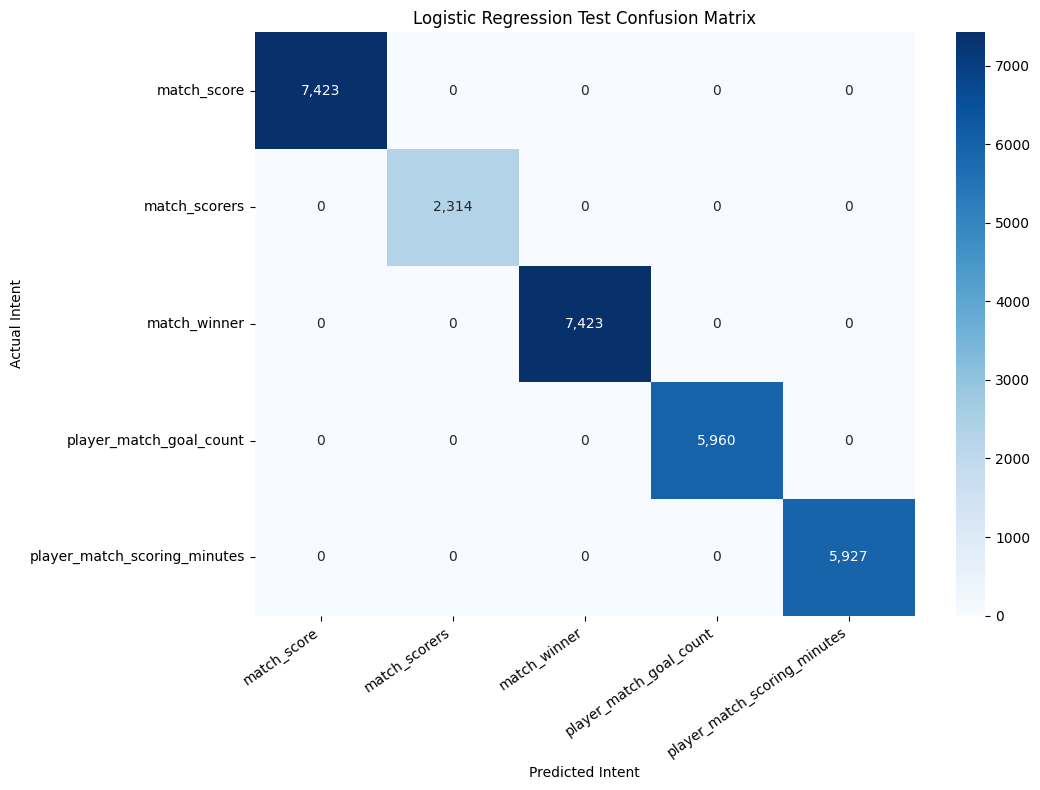

In [18]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix

class_labels = final_model.classes_

test_confusion_matrix = confusion_matrix(
    y_test,
    test_predictions,
    labels=class_labels
)

plt.figure(figsize=(11, 8))

sns.heatmap(
    test_confusion_matrix,
    annot=True,
    fmt=",d",
    cmap="Blues",
    xticklabels=class_labels,
    yticklabels=class_labels
)

plt.title("Logistic Regression Test Confusion Matrix")
plt.xlabel("Predicted Intent")
plt.ylabel("Actual Intent")
plt.xticks(rotation=35, ha="right")
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

In [19]:
# Create baseline test-results table
test_predictions = final_model.predict(X_test_tfidf)

test_results_df = (
    test_df[
        ["question", "intent"]
    ]
    .copy()
    .reset_index(drop=True)
)

test_results_df["predicted_intent"] = test_predictions

print("Test-results table created:", test_results_df.shape)
display(test_results_df.head())

Test-results table created: (29047, 3)


,question,intent,predicted_intent
0,"Which side won on November 30, 1872, England o...",match_winner,match_winner
1,"Who won, or was it a draw, when Wales played N...",match_winner,match_winner
2,"Which side won on 1886-03-13, England or North...",match_winner,match_winner
3,"Which side won on 12 March 1887, Northern Irel...",match_winner,match_winner
4,"Who won, or was it a draw, when England played...",match_winner,match_winner


## Add prediction confidence

In [20]:
test_probabilities = final_model.predict_proba(X_test_tfidf)

test_results_df["prediction_confidence"] = (
    test_probabilities.max(axis=1)
)

print("PREDICTION CONFIDENCE SUMMARY")
print("-" * 50)

print(
    test_results_df["prediction_confidence"]
    .describe()
    .round(4)
)

print("\nLowest-confidence test predictions:")

display(
    test_results_df.sort_values(
        "prediction_confidence"
    )[
        [
            "question",
            "intent",
            "predicted_intent",
            "prediction_confidence"
        ]
    ].head(15)
)

PREDICTION CONFIDENCE SUMMARY
--------------------------------------------------
count    29047.0000
mean         0.7344
std          0.0946
min          0.3909
25%          0.6726
50%          0.7450
75%          0.8074
max          0.9346
Name: prediction_confidence, dtype: float64

Lowest-confidence test predictions:


,question,intent,predicted_intent,prediction_confidence
5235,Who scored in the match between Solomon Island...,match_scorers,match_scorers,0.390909
5331,Who scored in the match between Saint Vincent ...,match_scorers,match_scorers,0.393179
5250,Who scored in the match between Burkina Faso a...,match_scorers,match_scorers,0.396017
24409,Who scored in the match between Vanuatu and Ne...,match_scorers,match_scorers,0.401105
14862,Who scored in the match between Hong Kong and ...,match_scorers,match_scorers,0.402381
24677,Who scored in the match between Tonga and Solo...,match_scorers,match_scorers,0.403353
5317,Which players recorded goals when Libya played...,match_scorers,match_scorers,0.405619
14940,Who scored in the match between Suriname and E...,match_scorers,match_scorers,0.406094
5280,Who scored in the match between Mongolia and S...,match_scorers,match_scorers,0.408830
24527,Who scored in the match between Niger and Bots...,match_scorers,match_scorers,0.411164


## Out-of-Template Robustness Evaluation

The original test set contains unseen football matches, but its questions were
generated using template families represented in the training data. Therefore,
a second evaluation set was manually created to examine whether the classifier
can generalize to less predictable wording.

This robustness set contains 50 manually written questions, with 10 examples
for each supported intent. The questions include informal wording, indirect
expressions, shortened sentences, and minor grammatical or spelling variations.

These questions were not used for model training, validation, hyperparameter
selection, or the original test evaluation. Results from this evaluation are
reported separately from the generated test-set results.

## Create manual robustness questions

In [21]:
manual_robustness_data = [
    # match_winner
    ("Which country came out on top in the Brazil Germany game?",
     "match_winner"),
    ("Between France and Argentina, who took the win?",
     "match_winner"),
    ("Tell me which side defeated the other when Spain faced Italy.",
     "match_winner"),
    ("Was Portugal or Netherlands the victorious team?",
     "match_winner"),
    ("Who walked away with the victory from England against Croatia?",
     "match_winner"),
    ("Which team got the better of Belgium in their game with Japan?",
     "match_winner"),
    ("Did Uruguay beat Ghana, or did Ghana beat Uruguay?",
     "match_winner"),
    ("Who ended up winning Morocco versus Canada?",
     "match_winner"),
    ("Which side was the winner of the Germany Argentina fixture?",
     "match_winner"),
    ("Who won btween Brazil and Chile?",
     "match_winner"),

    # match_score
    ("How many did Brazil and Germany finish with?",
     "match_score"),
    ("Give me the final numbers from France versus Argentina.",
     "match_score"),
    ("What did the scoreboard show after Spain played Italy?",
     "match_score"),
    ("How did Portugal Netherlands end score-wise?",
     "match_score"),
    ("Tell me the full-time scoreline for England against Croatia.",
     "match_score"),
    ("What were the scores for Belgium and Japan?",
     "match_score"),
    ("How many goals did each side have when Uruguay met Ghana?",
     "match_score"),
    ("What was on the board at full time in Morocco versus Canada?",
     "match_score"),
    ("Germany Argentina — what did it finish?",
     "match_score"),
    ("Wht was the final scor in Brazil versus Chile?",
     "match_score"),

    # match_scorers
    ("Name everyone who found the net in Brazil against Germany.",
     "match_scorers"),
    ("Which footballers got on the scoresheet in France versus Argentina?",
     "match_scorers"),
    ("Give me the names of the goal-getters from Spain Italy.",
     "match_scorers"),
    ("Who put the ball in the net during Portugal against Netherlands?",
     "match_scorers"),
    ("List the players responsible for the goals in England Croatia.",
     "match_scorers"),
    ("Whose names appeared on the scoresheet when Belgium met Japan?",
     "match_scorers"),
    ("Can I have all the scorers from Uruguay versus Ghana?",
     "match_scorers"),
    ("Who managed to find the back of the net in Morocco Canada?",
     "match_scorers"),
    ("Name the goal scorers for Germany against Argentina.",
     "match_scorers"),
    ("Who scord in the Brazil and Chile fixture?",
     "match_scorers"),

    # player_match_goal_count
    ("How often did Lionel Messi find the net in that fixture?",
     "player_match_goal_count"),
    ("What was Cristiano Ronaldo's goal tally for the game?",
     "player_match_goal_count"),
    ("Tell me the number of goals scored by Neymar in that match.",
     "player_match_goal_count"),
    ("Did Kylian Mbappe score once, twice, or more?",
     "player_match_goal_count"),
    ("What total did Harry Kane contribute in goals?",
     "player_match_goal_count"),
    ("How many times was Mohamed Salah on the scoresheet?",
     "player_match_goal_count"),
    ("Count Robert Lewandowski's goals in that game.",
     "player_match_goal_count"),
    ("What was Luis Suarez's scoring total for the fixture?",
     "player_match_goal_count"),
    ("How many did Erling Haaland put away in the match?",
     "player_match_goal_count"),
    ("How many gols did Antoine Griezmann get?",
     "player_match_goal_count"),

    # player_match_scoring_minutes
    ("At what points in the game did Lionel Messi find the net?",
     "player_match_scoring_minutes"),
    ("Give me the timestamps of Cristiano Ronaldo's goals.",
     "player_match_scoring_minutes"),
    ("When during the match did Neymar get on the scoresheet?",
     "player_match_scoring_minutes"),
    ("In which parts of the game did Kylian Mbappe score?",
     "player_match_scoring_minutes"),
    ("Tell me exactly when Harry Kane's goals happened.",
     "player_match_scoring_minutes"),
    ("What were the goal times for Mohamed Salah?",
     "player_match_scoring_minutes"),
    ("When did Robert Lewandowski put the ball in the net?",
     "player_match_scoring_minutes"),
    ("At which minute marks did Luis Suarez score?",
     "player_match_scoring_minutes"),
    ("How far into the game was it when Erling Haaland scored?",
     "player_match_scoring_minutes"),
    ("Wht minute did Antoine Griezmann find the net?",
     "player_match_scoring_minutes")
]

manual_robustness_df = pd.DataFrame(
    manual_robustness_data,
    columns=["question", "expected_intent"]
)

manual_robustness_df["question_clean"] = (
    manual_robustness_df["question"].apply(clean_question_text)
)

print("MANUAL ROBUSTNESS SET")
print("-" * 50)
print(f"Total questions: {len(manual_robustness_df)}")

display(
    manual_robustness_df["expected_intent"]
    .value_counts()
    .rename_axis("intent")
    .reset_index(name="question_count")
)

display(manual_robustness_df.head(10))

MANUAL ROBUSTNESS SET
--------------------------------------------------
Total questions: 50


,intent,question_count
0,match_winner,10
1,match_score,10
2,match_scorers,10
3,player_match_goal_count,10
4,player_match_scoring_minutes,10


,question,expected_intent,question_clean
0,Which country came out on top in the Brazil Ge...,match_winner,which country came out on top in the brazil ge...
1,"Between France and Argentina, who took the win?",match_winner,between france and argentina who took the win
2,Tell me which side defeated the other when Spa...,match_winner,tell me which side defeated the other when spa...
3,Was Portugal or Netherlands the victorious team?,match_winner,was portugal or netherlands the victorious team
4,Who walked away with the victory from England ...,match_winner,who walked away with the victory from england ...
5,Which team got the better of Belgium in their ...,match_winner,which team got the better of belgium in their ...
6,"Did Uruguay beat Ghana, or did Ghana beat Urug...",match_winner,did uruguay beat ghana or did ghana beat uruguay
7,Who ended up winning Morocco versus Canada?,match_winner,who ended up winning morocco versus canada
8,Which side was the winner of the Germany Argen...,match_winner,which side was the winner of the germany argen...
9,Who won btween Brazil and Chile?,match_winner,who won btween brazil and chile


## Evaluate the robustness set

In [22]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report
)

manual_features = tfidf_vectorizer.transform(
    manual_robustness_df["question_clean"]
)

manual_predictions = final_model.predict(manual_features)
manual_probabilities = final_model.predict_proba(manual_features)

manual_robustness_df["predicted_intent"] = manual_predictions
manual_robustness_df["prediction_confidence"] = (
    manual_probabilities.max(axis=1)
)

manual_robustness_df["correct_prediction"] = (
    manual_robustness_df["expected_intent"]
    == manual_robustness_df["predicted_intent"]
)

manual_accuracy = accuracy_score(
    manual_robustness_df["expected_intent"],
    manual_predictions
)

manual_macro_precision = precision_score(
    manual_robustness_df["expected_intent"],
    manual_predictions,
    average="macro",
    zero_division=0
)

manual_macro_recall = recall_score(
    manual_robustness_df["expected_intent"],
    manual_predictions,
    average="macro",
    zero_division=0
)

manual_macro_f1 = f1_score(
    manual_robustness_df["expected_intent"],
    manual_predictions,
    average="macro",
    zero_division=0
)

print("OUT-OF-TEMPLATE ROBUSTNESS RESULTS")
print("-" * 50)
print(f"Questions:          {len(manual_robustness_df)}")
print(f"Correct:            {manual_robustness_df['correct_prediction'].sum()}")
print(f"Incorrect:          {(~manual_robustness_df['correct_prediction']).sum()}")
print(f"Accuracy:           {manual_accuracy:.4f}")
print(f"Macro precision:    {manual_macro_precision:.4f}")
print(f"Macro recall:       {manual_macro_recall:.4f}")
print(f"Macro F1-score:     {manual_macro_f1:.4f}")
print(
    "Mean confidence:   "
    f"{manual_robustness_df['prediction_confidence'].mean():.4f}"
)

OUT-OF-TEMPLATE ROBUSTNESS RESULTS
--------------------------------------------------
Questions:          50
Correct:            32
Incorrect:          18
Accuracy:           0.6400
Macro precision:    0.6839
Macro recall:       0.6400
Macro F1-score:     0.6439
Mean confidence:   0.4607


## Classification report and errors

In [23]:
manual_report = classification_report(
    manual_robustness_df["expected_intent"],
    manual_robustness_df["predicted_intent"],
    output_dict=True,
    zero_division=0
)

manual_report_df = (
    pd.DataFrame(manual_report)
    .transpose()
    .round(4)
)

print("MANUAL ROBUSTNESS CLASSIFICATION REPORT")
display(manual_report_df)

manual_errors_df = manual_robustness_df[
    ~manual_robustness_df["correct_prediction"]
].copy()

print("\nMISCLASSIFIED MANUAL QUESTIONS")
print("-" * 50)

if len(manual_errors_df) == 0:
    print("No manual questions were misclassified.")
else:
    display(
        manual_errors_df[
            [
                "question",
                "expected_intent",
                "predicted_intent",
                "prediction_confidence"
            ]
        ].sort_values("prediction_confidence")
    )

MANUAL ROBUSTNESS CLASSIFICATION REPORT


,precision,recall,f1-score,support
match_score,0.5000,0.60,0.5455,10.00
match_scorers,1.0000,0.60,0.7500,10.00
match_winner,0.6667,0.80,0.7273,10.00
player_match_goal_count,0.5385,0.70,0.6087,10.00
player_match_scoring_minutes,0.7143,0.50,0.5882,10.00
accuracy,0.6400,0.64,0.6400,0.64
macro avg,0.6839,0.64,0.6439,50.00
weighted avg,0.6839,0.64,0.6439,50.00



MISCLASSIFIED MANUAL QUESTIONS
--------------------------------------------------


,question,expected_intent,predicted_intent,prediction_confidence
26,Can I have all the scorers from Uruguay versus...,match_scorers,match_score,0.245751
44,Tell me exactly when Harry Kane's goals happened.,player_match_scoring_minutes,player_match_goal_count,0.294539
31,What was Cristiano Ronaldo's goal tally for th...,player_match_goal_count,match_score,0.295682
33,"Did Kylian Mbappe score once, twice, or more?",player_match_goal_count,match_winner,0.301566
42,When during the match did Neymar get on the sc...,player_match_scoring_minutes,player_match_goal_count,0.301994
22,Give me the names of the goal-getters from Spa...,match_scorers,match_score,0.305797
4,Who walked away with the victory from England ...,match_winner,match_score,0.315085
49,Wht minute did Antoine Griezmann find the net?,player_match_scoring_minutes,player_match_goal_count,0.319479
41,Give me the timestamps of Cristiano Ronaldo's ...,player_match_scoring_minutes,match_score,0.322322
12,What did the scoreboard show after Spain playe...,match_score,match_winner,0.332203


### Robustness Result Interpretation

The Logistic Regression model achieved 64.00% accuracy and a macro F1-score
of 0.6439 on the 50 manually written out-of-template questions. This is
substantially lower than the 100% accuracy obtained on the generated test set.

The difference shows that separating matches between the training and test sets
prevented match-level overlap, but did not test generalization to completely new
question structures. The generated test questions used template families already
represented during training, whereas the manual questions contained unfamiliar
expressions, indirect wording, shortened sentences, and spelling variations.

The `match_scorers` intent achieved the highest precision (1.00), meaning every
question predicted as this class was correct. However, its recall was only 0.60,
meaning that four of its ten questions were incorrectly assigned to other classes.

The weakest class by F1-score was `match_score` (0.5455). Score questions were
confused with winner, goal-count, and scoring-minute intents. Questions about
individual players also produced confusion between goal counts and goal times.

The mean confidence was only 0.4607, compared with 0.7344 on the generated test
set. This provides further evidence that unfamiliar wording made the intent
boundaries less clear to the classifier.

## Manual robustness confusion matrix

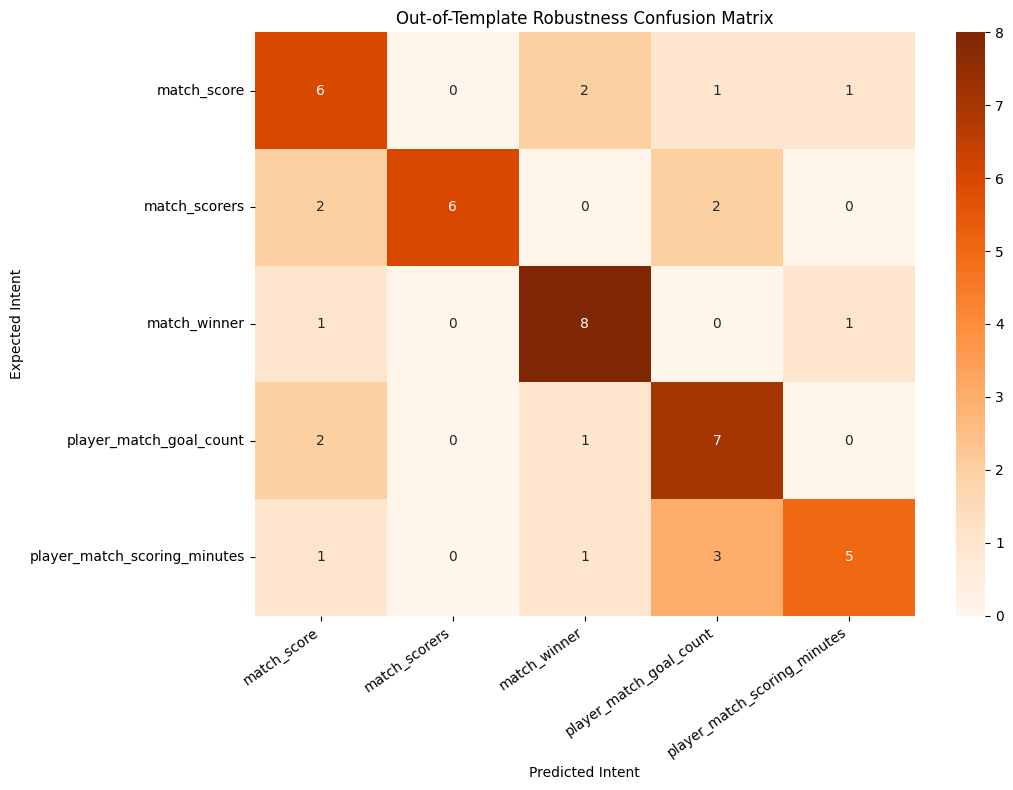

In [24]:
from sklearn.metrics import confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

manual_class_labels = final_model.classes_

manual_confusion_matrix = confusion_matrix(
    manual_robustness_df["expected_intent"],
    manual_robustness_df["predicted_intent"],
    labels=manual_class_labels
)

plt.figure(figsize=(11, 8))

sns.heatmap(
    manual_confusion_matrix,
    annot=True,
    fmt="d",
    cmap="Oranges",
    xticklabels=manual_class_labels,
    yticklabels=manual_class_labels
)

plt.title("Out-of-Template Robustness Confusion Matrix")
plt.xlabel("Predicted Intent")
plt.ylabel("Expected Intent")
plt.xticks(rotation=35, ha="right")
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

## Compare the two evaluation tracks

In [25]:
evaluation_comparison_df = pd.DataFrame({
    "evaluation_track": [
        "Generated test set: unseen matches, familiar templates",
        "Manual robustness set: unseen wording"
    ],
    "questions": [
        len(test_df),
        len(manual_robustness_df)
    ],
    "accuracy": [
        test_accuracy,
        manual_accuracy
    ],
    "macro_f1": [
        test_macro_f1,
        manual_macro_f1
    ],
    "mean_confidence": [
        test_results_df["prediction_confidence"].mean(),
        manual_robustness_df["prediction_confidence"].mean()
    ]
})

display(
    evaluation_comparison_df.style.format({
        "accuracy": "{:.4f}",
        "macro_f1": "{:.4f}",
        "mean_confidence": "{:.4f}"
    })
)

,evaluation_track,questions,accuracy,macro_f1,mean_confidence
0,"Generated test set: unseen matches, familiar templates",29047,1.0000,1.0000,0.7344
1,Manual robustness set: unseen wording,50,0.6400,0.6439,0.4607


### Manual Error Analysis

The 18 incorrect predictions reveal several limitations:

1. **Unfamiliar synonyms**

   Expressions such as “goal-getters,” “timestamps,” “goal tally,” and “came out
   on top” were not learned as reliably as the vocabulary used by the generated
   templates.

2. **Overlap between related intents**

   Expressions such as “find the net” can refer to who scored, how many goals a
   player scored, or when the player scored. A bag-of-words representation cannot
   always determine the intended meaning from these shared terms.

3. **Dependence on explicit cue words**

   Questions containing familiar words such as “score,” “won,” “minute,” or
   “how many goals” are easier to classify. Indirect questions such as “what did
   it finish?” remove these strong cues.

4. **Sensitivity to spelling variations**

   Misspellings such as “Wht” and less familiar formulations reduced performance
   because word-based TF-IDF treats altered spellings as different vocabulary.

5. **Limited semantic understanding**

   TF-IDF represents word occurrence patterns rather than the full contextual
   meaning of a question. Consequently, semantically related sentences can receive
   different representations when they use different vocabulary.

## Model Improvement Protocol

The manually written robustness set is retained as a final out-of-template test set.
It will not be used to select features, hyperparameters, or model configurations.

Model improvements will instead be evaluated using a separate development track.
This prevents the model-selection process from becoming adapted to the 50 manual
robustness questions.

The proposed improvement combines word-level and character-level TF-IDF features.
Word features represent normal vocabulary and phrases, while character features
can provide additional robustness to spelling variations and related word forms.

## Template-Disjoint Development Evaluation

The dataset contains explicit `template_id` and `template_family` fields. All
questions in the original generated evaluation track use templates represented
during training, which explains why the unseen-match test remains linguistically
easy.

For model improvement, two template IDs from each intent are held out. Candidate
models are trained using the remaining training questions and evaluated using
validation questions belonging to the held-out templates.

This creates a development evaluation with two separation conditions:

1. Development matches are absent from candidate training because the original
   match-disjoint split is preserved.
2. Development template IDs are absent from candidate training.

The original test set and the 50 manually written robustness questions are not
used for feature or hyperparameter selection.

In [26]:
# Restore template metadata to the existing split DataFrames

template_metadata_columns = [
    "question_id",
    "template_id",
    "template_family",
    "template_seen_in_training",
    "question_variant"
]

# Confirm that question_id can safely identify each QA record
assert qa_dataset["question_id"].notna().all(), (
    "qa_dataset contains missing question_id values."
)

assert qa_dataset["question_id"].is_unique, (
    "question_id is not unique in qa_dataset."
)

template_metadata_df = (
    qa_dataset[template_metadata_columns]
    .drop_duplicates(subset=["question_id"])
    .copy()
)

def restore_template_metadata(split_df, split_name):
    if "question_id" not in split_df.columns:
        raise KeyError(
            f"{split_name} does not contain question_id, "
            "so metadata cannot yet be matched safely."
        )

    # Remove partially existing metadata to prevent _x and _y columns
    metadata_to_remove = [
        column_name
        for column_name in template_metadata_columns[1:]
        if column_name in split_df.columns
    ]

    repaired_df = split_df.drop(
        columns=metadata_to_remove
    ).merge(
        template_metadata_df,
        on="question_id",
        how="left",
        validate="many_to_one"
    )

    assert len(repaired_df) == len(split_df), (
        f"{split_name} changed size during metadata restoration."
    )

    assert repaired_df["template_id"].notna().all(), (
        f"Some {split_name} records could not be matched "
        "to a template_id."
    )

    return repaired_df


train_df = restore_template_metadata(
    train_df,
    "train_df"
)

validation_df = restore_template_metadata(
    validation_df,
    "validation_df"
)

test_df = restore_template_metadata(
    test_df,
    "test_df"
)

print("TEMPLATE METADATA RESTORED")
print("-" * 60)

for split_name, split_df in [
    ("Training", train_df),
    ("Validation", validation_df),
    ("Test", test_df)
]:
    print(
        f"{split_name}: "
        f"{len(split_df):,} questions, "
        f"{split_df['template_id'].nunique()} template IDs"
    )

print("\nRelevant training columns:")
print([
    column_name
    for column_name in train_df.columns
    if "template" in column_name or column_name == "question_variant"
])

TEMPLATE METADATA RESTORED
------------------------------------------------------------
Training: 135,939 questions, 40 template IDs
Validation: 29,173 questions, 40 template IDs
Test: 29,047 questions, 40 template IDs

Relevant training columns:
['template_id', 'template_family', 'template_seen_in_training', 'question_variant']


## Verify templates available by intent

In [27]:
template_intent_table = pd.crosstab(
    train_df["template_id"],
    train_df["intent"]
)

print("TRAINING TEMPLATE DISTRIBUTION")
print("-" * 60)

display(template_intent_table)

templates_per_intent = (
    train_df.groupby("intent")["template_id"]
    .nunique()
    .sort_index()
    .rename("unique_template_ids")
    .reset_index()
)

display(templates_per_intent)

TRAINING TEMPLATE DISTRIBUTION
------------------------------------------------------------


intent,match_score,match_scorers,match_winner,player_match_goal_count,player_match_scoring_minutes
template_id,,,,,
PGCOUNT_SEEN_01,0,0,0,3463,0
PGCOUNT_SEEN_02,0,0,0,3538,0
PGCOUNT_SEEN_03,0,0,0,3456,0
PGCOUNT_SEEN_04,0,0,0,3489,0
PGCOUNT_SEEN_05,0,0,0,3470,0
PGCOUNT_SEEN_06,0,0,0,3508,0
PGCOUNT_SEEN_07,0,0,0,3517,0
PGCOUNT_SEEN_08,0,0,0,3521,0
PGMINUTE_SEEN_01,0,0,0,0,3438


,intent,unique_template_ids
0,match_score,8
1,match_scorers,8
2,match_winner,8
3,player_match_goal_count,8
4,player_match_scoring_minutes,8


## Select held-out template IDs

In [28]:
HELD_OUT_TEMPLATES_PER_INTENT = 2

held_out_template_records = []

for intent_name in sorted(train_df["intent"].unique()):
    intent_template_ids = sorted(
        train_df.loc[
            train_df["intent"] == intent_name,
            "template_id"
        ].dropna().unique()
    )

    if len(intent_template_ids) <= HELD_OUT_TEMPLATES_PER_INTENT:
        raise ValueError(
            f"Not enough templates for {intent_name}: "
            f"{len(intent_template_ids)} found."
        )

    selected_template_ids = intent_template_ids[
        -HELD_OUT_TEMPLATES_PER_INTENT:
    ]

    for template_id in selected_template_ids:
        held_out_template_records.append({
            "intent": intent_name,
            "template_id": template_id
        })

held_out_templates_df = pd.DataFrame(
    held_out_template_records
)

held_out_template_ids = set(
    held_out_templates_df["template_id"]
)

print("HELD-OUT DEVELOPMENT TEMPLATES")
print("-" * 60)

display(held_out_templates_df)

HELD-OUT DEVELOPMENT TEMPLATES
------------------------------------------------------------


,intent,template_id
0,match_score,SCORE_SEEN_07
1,match_score,SCORE_SEEN_08
2,match_scorers,SCORERS_SEEN_07
3,match_scorers,SCORERS_SEEN_08
4,match_winner,WIN_SEEN_07
5,match_winner,WIN_SEEN_08
6,player_match_goal_count,PGCOUNT_SEEN_07
7,player_match_goal_count,PGCOUNT_SEEN_08
8,player_match_scoring_minutes,PGMINUTE_SEEN_07
9,player_match_scoring_minutes,PGMINUTE_SEEN_08


## Create candidate-training and development sets

In [29]:
candidate_train_df = train_df[
    ~train_df["template_id"].isin(held_out_template_ids)
].copy()

template_dev_df = validation_df[
    validation_df["template_id"].isin(held_out_template_ids)
].copy()

print("TEMPLATE-DISJOINT DEVELOPMENT SPLIT")
print("-" * 60)
print(f"Original training questions:  {len(train_df):,}")
print(f"Candidate training questions: {len(candidate_train_df):,}")
print(f"Development questions:        {len(template_dev_df):,}")
print(f"Held-out template IDs:        {len(held_out_template_ids)}")

print("\nCandidate-training distribution:")
display(
    candidate_train_df["intent"]
    .value_counts()
    .sort_index()
    .rename("questions")
    .reset_index()
)

print("\nDevelopment distribution:")
display(
    template_dev_df["intent"]
    .value_counts()
    .sort_index()
    .rename("questions")
    .reset_index()
)

print("\nDevelopment templates:")
display(
    template_dev_df.groupby(
        ["intent", "template_id", "template_family"]
    )
    .size()
    .rename("questions")
    .reset_index()
    .sort_values(["intent", "template_id"])
)

TEMPLATE-DISJOINT DEVELOPMENT SPLIT
------------------------------------------------------------
Original training questions:  135,939
Candidate training questions: 101,631
Development questions:        7,199
Held-out template IDs:        10

Candidate-training distribution:


,intent,questions
0,match_score,25843
1,match_scorers,8115
2,match_winner,26012
3,player_match_goal_count,20924
4,player_match_scoring_minutes,20737



Development distribution:


,intent,questions
0,match_score,1825
1,match_scorers,551
2,match_winner,1889
3,player_match_goal_count,1451
4,player_match_scoring_minutes,1483



Development templates:


,intent,template_id,template_family,questions
0,match_score,SCORE_SEEN_07,report,894
1,match_score,SCORE_SEEN_08,goals,931
2,match_scorers,SCORERS_SEEN_07,responsible,268
3,match_scorers,SCORERS_SEEN_08,list,283
4,match_winner,WIN_SEEN_07,result,956
5,match_winner,WIN_SEEN_08,secured,933
6,player_match_goal_count,PGCOUNT_SEEN_07,record,732
7,player_match_goal_count,PGCOUNT_SEEN_08,net,719
8,player_match_scoring_minutes,PGMINUTE_SEEN_07,list,731
9,player_match_scoring_minutes,PGMINUTE_SEEN_08,timed,752


## Validate both separation conditions

In [30]:
training_template_ids = set(
    candidate_train_df["template_id"].dropna()
)

development_template_ids = set(
    template_dev_df["template_id"].dropna()
)

training_match_ids = set(
    candidate_train_df["match_id"].dropna()
)

development_match_ids = set(
    template_dev_df["match_id"].dropna()
)

template_overlap = (
    training_template_ids
    & development_template_ids
)

match_overlap = (
    training_match_ids
    & development_match_ids
)

print("DEVELOPMENT LEAKAGE CHECK")
print("-" * 60)
print(
    "Template IDs shared between candidate training and development:",
    len(template_overlap)
)
print(
    "Match IDs shared between candidate training and development:",
    len(match_overlap)
)

assert len(template_overlap) == 0, (
    "Template leakage was detected."
)

assert len(match_overlap) == 0, (
    "Match leakage was detected."
)

assert set(template_dev_df["intent"]) == set(
    train_df["intent"]
), "One or more intents are absent from development."

assert len(template_dev_df) > 0, (
    "The development set is empty."
)

print("\nValidation passed:")
print("- Candidate training and development are template-disjoint.")
print("- Candidate training and development are match-disjoint.")
print("- Every supported intent is present in development.")

DEVELOPMENT LEAKAGE CHECK
------------------------------------------------------------
Template IDs shared between candidate training and development: 0
Match IDs shared between candidate training and development: 0

Validation passed:
- Candidate training and development are template-disjoint.
- Candidate training and development are match-disjoint.
- Every supported intent is present in development.


## Candidate Model Comparison

Two Logistic Regression configurations are compared using the template-disjoint
development set.

1. **Baseline candidate:** the existing word-level TF-IDF representation.
2. **Improved candidate:** word-level and character-level TF-IDF features combined.

Both candidates use the same candidate-training records and are evaluated on the
same development questions. Macro F1-score is the primary selection metric because
it gives equal importance to all five intents, including the smaller
`match_scorers` class.

The original generated test set and manual robustness set remain untouched during
this comparison.

## Prepare candidate text

In [31]:
candidate_train_text = (
    candidate_train_df["question_clean"]
    if "question_clean" in candidate_train_df.columns
    else candidate_train_df["question"].apply(clean_question_text)
)

template_dev_text = (
    template_dev_df["question_clean"]
    if "question_clean" in template_dev_df.columns
    else template_dev_df["question"].apply(clean_question_text)
)

candidate_train_labels = candidate_train_df["intent"]
template_dev_labels = template_dev_df["intent"]

print("CANDIDATE DATA PREPARED")
print("-" * 60)
print(f"Candidate-training questions: {len(candidate_train_text):,}")
print(f"Development questions:        {len(template_dev_text):,}")
print(f"Missing candidate text:       {candidate_train_text.isna().sum()}")
print(f"Missing development text:     {template_dev_text.isna().sum()}")

CANDIDATE DATA PREPARED
------------------------------------------------------------
Candidate-training questions: 101,631
Development questions:        7,199
Missing candidate text:       0
Missing development text:     0


## Train the baseline candidate

In [32]:
from sklearn.base import clone
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score
)

candidate_word_vectorizer = clone(tfidf_vectorizer)
candidate_baseline_model = clone(final_model)

candidate_train_word_features = (
    candidate_word_vectorizer.fit_transform(candidate_train_text)
)

template_dev_word_features = (
    candidate_word_vectorizer.transform(template_dev_text)
)

candidate_baseline_model.fit(
    candidate_train_word_features,
    candidate_train_labels
)

baseline_dev_predictions = candidate_baseline_model.predict(
    template_dev_word_features
)

baseline_dev_accuracy = accuracy_score(
    template_dev_labels,
    baseline_dev_predictions
)

baseline_dev_macro_precision = precision_score(
    template_dev_labels,
    baseline_dev_predictions,
    average="macro",
    zero_division=0
)

baseline_dev_macro_recall = recall_score(
    template_dev_labels,
    baseline_dev_predictions,
    average="macro",
    zero_division=0
)

baseline_dev_macro_f1 = f1_score(
    template_dev_labels,
    baseline_dev_predictions,
    average="macro",
    zero_division=0
)

print("BASELINE: WORD TF-IDF + LOGISTIC REGRESSION")
print("-" * 60)
print(f"Feature count:    {candidate_train_word_features.shape[1]:,}")
print(f"Accuracy:         {baseline_dev_accuracy:.4f}")
print(f"Macro precision:  {baseline_dev_macro_precision:.4f}")
print(f"Macro recall:     {baseline_dev_macro_recall:.4f}")
print(f"Macro F1-score:   {baseline_dev_macro_f1:.4f}")

BASELINE: WORD TF-IDF + LOGISTIC REGRESSION
------------------------------------------------------------
Feature count:    30,000
Accuracy:         0.5569
Macro precision:  0.5212
Macro recall:     0.4953
Macro F1-score:   0.4666


## Train the word-and-character candidate

In [33]:
from sklearn.pipeline import FeatureUnion
from sklearn.feature_extraction.text import TfidfVectorizer

candidate_combined_vectorizer = FeatureUnion([
    (
        "word_tfidf",
        clone(tfidf_vectorizer)
    ),
    (
        "character_tfidf",
        TfidfVectorizer(
            analyzer="char_wb",
            ngram_range=(3, 5),
            min_df=2,
            max_features=75000,
            sublinear_tf=True
        )
    )
])

candidate_combined_model = clone(final_model)

candidate_train_combined_features = (
    candidate_combined_vectorizer.fit_transform(candidate_train_text)
)

template_dev_combined_features = (
    candidate_combined_vectorizer.transform(template_dev_text)
)

candidate_combined_model.fit(
    candidate_train_combined_features,
    candidate_train_labels
)

combined_dev_predictions = candidate_combined_model.predict(
    template_dev_combined_features
)

combined_dev_accuracy = accuracy_score(
    template_dev_labels,
    combined_dev_predictions
)

combined_dev_macro_precision = precision_score(
    template_dev_labels,
    combined_dev_predictions,
    average="macro",
    zero_division=0
)

combined_dev_macro_recall = recall_score(
    template_dev_labels,
    combined_dev_predictions,
    average="macro",
    zero_division=0
)

combined_dev_macro_f1 = f1_score(
    template_dev_labels,
    combined_dev_predictions,
    average="macro",
    zero_division=0
)

print("IMPROVED: WORD + CHARACTER TF-IDF")
print("-" * 60)
print(f"Feature count:    {candidate_train_combined_features.shape[1]:,}")
print(f"Accuracy:         {combined_dev_accuracy:.4f}")
print(f"Macro precision:  {combined_dev_macro_precision:.4f}")
print(f"Macro recall:     {combined_dev_macro_recall:.4f}")
print(f"Macro F1-score:   {combined_dev_macro_f1:.4f}")

IMPROVED: WORD + CHARACTER TF-IDF
------------------------------------------------------------
Feature count:    105,000
Accuracy:         0.5702
Macro precision:  0.7067
Macro recall:     0.5302
Macro F1-score:   0.5230


## Compare development results

In [34]:
candidate_comparison_df = pd.DataFrame({
    "candidate_model": [
        "Word TF-IDF baseline",
        "Word + character TF-IDF"
    ],
    "feature_count": [
        candidate_train_word_features.shape[1],
        candidate_train_combined_features.shape[1]
    ],
    "accuracy": [
        baseline_dev_accuracy,
        combined_dev_accuracy
    ],
    "macro_precision": [
        baseline_dev_macro_precision,
        combined_dev_macro_precision
    ],
    "macro_recall": [
        baseline_dev_macro_recall,
        combined_dev_macro_recall
    ],
    "macro_f1": [
        baseline_dev_macro_f1,
        combined_dev_macro_f1
    ]
})

candidate_comparison_df["macro_f1_change"] = (
    candidate_comparison_df["macro_f1"]
    - baseline_dev_macro_f1
)

print("TEMPLATE-DISJOINT DEVELOPMENT COMPARISON")
display(
    candidate_comparison_df.style.format({
        "accuracy": "{:.4f}",
        "macro_precision": "{:.4f}",
        "macro_recall": "{:.4f}",
        "macro_f1": "{:.4f}",
        "macro_f1_change": "{:+.4f}"
    })
)

if combined_dev_macro_f1 > baseline_dev_macro_f1:
    selected_candidate_name = "Word + character TF-IDF"
    print(
        "\nSelected candidate:",
        selected_candidate_name,
        "(higher development macro F1)"
    )
elif combined_dev_macro_f1 < baseline_dev_macro_f1:
    selected_candidate_name = "Word TF-IDF baseline"
    print(
        "\nSelected candidate:",
        selected_candidate_name,
        "(higher development macro F1)"
    )
else:
    selected_candidate_name = "Word TF-IDF baseline"
    print(
        "\nSelected candidate:",
        selected_candidate_name,
        "(equal macro F1; simpler model preferred)"
    )

TEMPLATE-DISJOINT DEVELOPMENT COMPARISON


,candidate_model,feature_count,accuracy,macro_precision,macro_recall,macro_f1,macro_f1_change
0,Word TF-IDF baseline,30000,0.5569,0.5212,0.4953,0.4666,+0.0000
1,Word + character TF-IDF,105000,0.5702,0.7067,0.5302,0.5230,+0.0564



Selected candidate: Word + character TF-IDF (higher development macro F1)


## Candidate Selection

The word-and-character TF-IDF configuration was selected using the
template-disjoint development set.

The word-only baseline achieved 0.4666 macro F1 and 55.69% accuracy.
Adding character-level features increased macro F1 to 0.5230 and accuracy
to 57.02%. The absolute macro F1 improvement was 0.0564.

Character features therefore improved generalization to unseen template
families. However, the development accuracy remained substantially below the
earlier generated test result, confirming that unseen wording is more difficult
than unseen matches using familiar templates.

Following model selection, the chosen configuration is retrained on the complete
original training split. Neither the test split nor the manually written
robustness set is used for fitting the final improved model.

## Retrain the selected configuration

In [35]:
import numpy as np
from sklearn.pipeline import FeatureUnion
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.base import clone

full_train_text = (
    train_df["question_clean"]
    if "question_clean" in train_df.columns
    else train_df["question"].apply(clean_question_text)
)

full_train_labels = train_df["intent"]

improved_word_vectorizer = clone(tfidf_vectorizer)

# Prevent the harmless dtype warning if dtype was stored as a string
improved_word_vectorizer.set_params(dtype=np.float32)

final_improved_vectorizer = FeatureUnion([
    (
        "word_tfidf",
        improved_word_vectorizer
    ),
    (
        "character_tfidf",
        TfidfVectorizer(
            analyzer="char_wb",
            ngram_range=(3, 5),
            min_df=2,
            max_features=75000,
            sublinear_tf=True,
            dtype=np.float32
        )
    )
])

final_improved_model = clone(final_model)

full_train_combined_features = (
    final_improved_vectorizer.fit_transform(full_train_text)
)

final_improved_model.fit(
    full_train_combined_features,
    full_train_labels
)

print("FINAL IMPROVED MODEL TRAINED")
print("-" * 60)
print(f"Training questions: {len(full_train_text):,}")
print(
    f"Combined features:  "
    f"{full_train_combined_features.shape[1]:,}"
)
print(
    "Training template IDs:",
    train_df["template_id"].nunique()
)

FINAL IMPROVED MODEL TRAINED
------------------------------------------------------------
Training questions: 135,939
Combined features:  105,000
Training template IDs: 40


## Evaluate on the generated test set

In [36]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report
)

final_test_text = (
    test_df["question_clean"]
    if "question_clean" in test_df.columns
    else test_df["question"].apply(clean_question_text)
)

final_test_features = final_improved_vectorizer.transform(
    final_test_text
)

improved_test_predictions = final_improved_model.predict(
    final_test_features
)

improved_test_probabilities = final_improved_model.predict_proba(
    final_test_features
)

improved_test_accuracy = accuracy_score(
    test_df["intent"],
    improved_test_predictions
)

improved_test_macro_precision = precision_score(
    test_df["intent"],
    improved_test_predictions,
    average="macro",
    zero_division=0
)

improved_test_macro_recall = recall_score(
    test_df["intent"],
    improved_test_predictions,
    average="macro",
    zero_division=0
)

improved_test_macro_f1 = f1_score(
    test_df["intent"],
    improved_test_predictions,
    average="macro",
    zero_division=0
)

improved_test_mean_confidence = (
    improved_test_probabilities.max(axis=1).mean()
)

print("IMPROVED MODEL: GENERATED TEST RESULTS")
print("-" * 60)
print(f"Questions:          {len(test_df):,}")
print(f"Accuracy:           {improved_test_accuracy:.4f}")
print(f"Macro precision:    {improved_test_macro_precision:.4f}")
print(f"Macro recall:       {improved_test_macro_recall:.4f}")
print(f"Macro F1-score:     {improved_test_macro_f1:.4f}")
print(f"Mean confidence:    {improved_test_mean_confidence:.4f}")

improved_test_report_df = pd.DataFrame(
    classification_report(
        test_df["intent"],
        improved_test_predictions,
        output_dict=True,
        zero_division=0
    )
).transpose().round(4)

display(improved_test_report_df)

IMPROVED MODEL: GENERATED TEST RESULTS
------------------------------------------------------------
Questions:          29,047
Accuracy:           1.0000
Macro precision:    1.0000
Macro recall:       1.0000
Macro F1-score:     1.0000
Mean confidence:    0.8320


,precision,recall,f1-score,support
match_score,1.0,1.0,1.0,7423.0
match_scorers,1.0,1.0,1.0,2314.0
match_winner,1.0,1.0,1.0,7423.0
player_match_goal_count,1.0,1.0,1.0,5960.0
player_match_scoring_minutes,1.0,1.0,1.0,5927.0
accuracy,1.0,1.0,1.0,1.0
macro avg,1.0,1.0,1.0,29047.0
weighted avg,1.0,1.0,1.0,29047.0


## One final manual robustness evaluation

In [37]:
final_manual_text = (
    manual_robustness_df["question_clean"]
    if "question_clean" in manual_robustness_df.columns
    else manual_robustness_df["question"].apply(clean_question_text)
)

final_manual_features = final_improved_vectorizer.transform(
    final_manual_text
)

improved_manual_predictions = final_improved_model.predict(
    final_manual_features
)

improved_manual_probabilities = final_improved_model.predict_proba(
    final_manual_features
)

improved_manual_accuracy = accuracy_score(
    manual_robustness_df["expected_intent"],
    improved_manual_predictions
)

improved_manual_macro_precision = precision_score(
    manual_robustness_df["expected_intent"],
    improved_manual_predictions,
    average="macro",
    zero_division=0
)

improved_manual_macro_recall = recall_score(
    manual_robustness_df["expected_intent"],
    improved_manual_predictions,
    average="macro",
    zero_division=0
)

improved_manual_macro_f1 = f1_score(
    manual_robustness_df["expected_intent"],
    improved_manual_predictions,
    average="macro",
    zero_division=0
)

improved_manual_mean_confidence = (
    improved_manual_probabilities.max(axis=1).mean()
)

print("FINAL IMPROVED MANUAL ROBUSTNESS RESULTS")
print("-" * 60)
print(f"Questions:          {len(manual_robustness_df)}")
print(
    "Correct:            "
    f"{(improved_manual_predictions == manual_robustness_df['expected_intent']).sum()}"
)
print(f"Accuracy:           {improved_manual_accuracy:.4f}")
print(f"Macro precision:    {improved_manual_macro_precision:.4f}")
print(f"Macro recall:       {improved_manual_macro_recall:.4f}")
print(f"Macro F1-score:     {improved_manual_macro_f1:.4f}")
print(f"Mean confidence:    {improved_manual_mean_confidence:.4f}")

improved_manual_report_df = pd.DataFrame(
    classification_report(
        manual_robustness_df["expected_intent"],
        improved_manual_predictions,
        output_dict=True,
        zero_division=0
    )
).transpose().round(4)

display(improved_manual_report_df)

FINAL IMPROVED MANUAL ROBUSTNESS RESULTS
------------------------------------------------------------
Questions:          50
Correct:            37
Accuracy:           0.7400
Macro precision:    0.7925
Macro recall:       0.7400
Macro F1-score:     0.7421
Mean confidence:    0.5397


,precision,recall,f1-score,support
match_score,0.8571,0.60,0.7059,10.00
match_scorers,1.0000,0.70,0.8235,10.00
match_winner,0.8000,0.80,0.8000,10.00
player_match_goal_count,0.5556,1.00,0.7143,10.00
player_match_scoring_minutes,0.7500,0.60,0.6667,10.00
accuracy,0.7400,0.74,0.7400,0.74
macro avg,0.7925,0.74,0.7421,50.00
weighted avg,0.7925,0.74,0.7421,50.00


## Compare baseline and improved robustness

In [38]:
final_robustness_comparison_df = pd.DataFrame({
    "model": [
        "Word TF-IDF baseline",
        "Word + character TF-IDF"
    ],
    "accuracy": [
        manual_accuracy,
        improved_manual_accuracy
    ],
    "macro_precision": [
        manual_macro_precision,
        improved_manual_macro_precision
    ],
    "macro_recall": [
        manual_macro_recall,
        improved_manual_macro_recall
    ],
    "macro_f1": [
        manual_macro_f1,
        improved_manual_macro_f1
    ],
    "mean_confidence": [
        manual_robustness_df[
            "prediction_confidence"
        ].mean(),
        improved_manual_mean_confidence
    ]
})

final_robustness_comparison_df["accuracy_change"] = (
    final_robustness_comparison_df["accuracy"]
    - manual_accuracy
)

final_robustness_comparison_df["macro_f1_change"] = (
    final_robustness_comparison_df["macro_f1"]
    - manual_macro_f1
)

print("FINAL MANUAL ROBUSTNESS COMPARISON")

display(
    final_robustness_comparison_df.style.format({
        "accuracy": "{:.4f}",
        "macro_precision": "{:.4f}",
        "macro_recall": "{:.4f}",
        "macro_f1": "{:.4f}",
        "mean_confidence": "{:.4f}",
        "accuracy_change": "{:+.4f}",
        "macro_f1_change": "{:+.4f}"
    })
)

FINAL MANUAL ROBUSTNESS COMPARISON


,model,accuracy,macro_precision,macro_recall,macro_f1,mean_confidence,accuracy_change,macro_f1_change
0,Word TF-IDF baseline,0.6400,0.6839,0.6400,0.6439,0.4607,+0.0000,+0.0000
1,Word + character TF-IDF,0.7400,0.7925,0.7400,0.7421,0.5397,+0.1000,+0.0981


## Final Improved Model Results

After model selection, the word-and-character TF-IDF configuration was retrained
using all 135,939 questions in the original training split. All 40 generated
template IDs were restored for final training.

### Generated Test Evaluation

The improved model achieved 100% accuracy and 1.0000 macro F1 on the 29,047-question
generated test set. Its mean prediction confidence was 0.8320, compared with 0.7344
for the word-only baseline.

This perfect result must be interpreted carefully. Although the test matches were
unseen during training, their question templates were represented in the training
data. Therefore, this evaluation demonstrates strong generalization to unseen
football matches under familiar generated wording, rather than complete
generalization to naturally written questions.

### Manual Robustness Evaluation

On the 50 manually written out-of-template questions, the improved model correctly
classified 37 questions and achieved:

- Accuracy: 0.7400
- Macro precision: 0.7925
- Macro recall: 0.7400
- Macro F1-score: 0.7421
- Mean confidence: 0.5397

Compared with the word-only baseline, manual accuracy increased from 0.6400 to
0.7400, while macro F1 increased from 0.6439 to 0.7421. These represent absolute
improvements of 0.1000 and 0.0981 respectively.

The results support the development-set selection decision: character n-grams
improved robustness to unfamiliar vocabulary, word forms, and spelling variations
without reducing performance on the generated test set.

## Improved manual confusion matrix

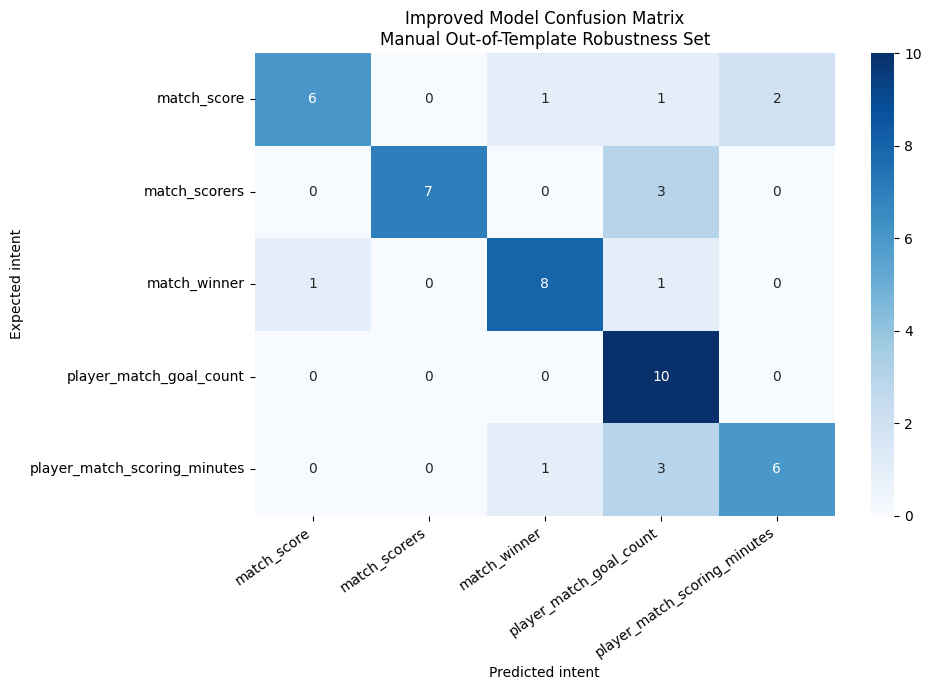

In [39]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

intent_order = sorted(
    manual_robustness_df["expected_intent"].unique()
)

improved_manual_confusion_matrix = confusion_matrix(
    manual_robustness_df["expected_intent"],
    improved_manual_predictions,
    labels=intent_order
)

plt.figure(figsize=(10, 7))

sns.heatmap(
    improved_manual_confusion_matrix,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=intent_order,
    yticklabels=intent_order
)

plt.title(
    "Improved Model Confusion Matrix\n"
    "Manual Out-of-Template Robustness Set"
)
plt.xlabel("Predicted intent")
plt.ylabel("Expected intent")
plt.xticks(rotation=35, ha="right")
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

## Inspect the 13 remaining errors

In [40]:
improved_manual_analysis_df = (
    manual_robustness_df.copy()
)

improved_manual_analysis_df["baseline_prediction"] = (
    manual_robustness_df["predicted_intent"]
)

improved_manual_analysis_df["improved_prediction"] = (
    improved_manual_predictions
)

improved_manual_analysis_df["improved_confidence"] = (
    improved_manual_probabilities.max(axis=1)
)

improved_manual_analysis_df["improved_correct"] = (
    improved_manual_analysis_df["expected_intent"]
    == improved_manual_analysis_df["improved_prediction"]
)

remaining_improved_errors_df = (
    improved_manual_analysis_df.loc[
        ~improved_manual_analysis_df["improved_correct"],
        [
            "question",
            "expected_intent",
            "baseline_prediction",
            "improved_prediction",
            "improved_confidence"
        ]
    ]
    .sort_values(
        "improved_confidence",
        ascending=False
    )
    .reset_index(drop=True)
)

print("REMAINING IMPROVED-MODEL ERRORS")
print("-" * 60)
print(f"Incorrect questions: {len(remaining_improved_errors_df)}")

display(
    remaining_improved_errors_df.style.format({
        "improved_confidence": "{:.4f}"
    })
)

REMAINING IMPROVED-MODEL ERRORS
------------------------------------------------------------
Incorrect questions: 13


,question,expected_intent,baseline_prediction,improved_prediction,improved_confidence
0,Germany Argentina — what did it finish?,match_score,match_winner,match_winner,0.7752
1,What were the scores for Belgium and Japan?,match_score,player_match_scoring_minutes,player_match_scoring_minutes,0.7214
2,Who put the ball in the net during Portugal against Netherlands?,match_scorers,player_match_goal_count,player_match_goal_count,0.5524
3,How many did Brazil and Germany finish with?,match_score,player_match_goal_count,player_match_goal_count,0.4547
4,Give me the timestamps of Cristiano Ronaldo's goals.,player_match_scoring_minutes,match_score,player_match_goal_count,0.4443
5,Who managed to find the back of the net in Morocco Canada?,match_scorers,player_match_goal_count,player_match_goal_count,0.4103
6,Tell me exactly when Harry Kane's goals happened.,player_match_scoring_minutes,player_match_goal_count,player_match_goal_count,0.4051
7,Which country came out on top in the Brazil Germany game?,match_winner,player_match_scoring_minutes,player_match_goal_count,0.3861
8,What was on the board at full time in Morocco versus Canada?,match_score,match_score,player_match_scoring_minutes,0.3741
9,Who walked away with the victory from England against Croatia?,match_winner,match_score,match_score,0.3346


## Measure which baseline errors were fixed

In [41]:
baseline_correct = (
    manual_robustness_df["predicted_intent"]
    == manual_robustness_df["expected_intent"]
)

improved_correct = (
    improved_manual_predictions
    == manual_robustness_df["expected_intent"]
)

fixed_by_improved_model = (
    (~baseline_correct) & improved_correct
)

new_errors_from_improved_model = (
    baseline_correct & (~improved_correct)
)

print("ROBUSTNESS ERROR CHANGES")
print("-" * 60)
print(
    "Baseline errors corrected by improved model:",
    fixed_by_improved_model.sum()
)
print(
    "Previously correct questions now incorrect:",
    new_errors_from_improved_model.sum()
)
print(
    "Net increase in correct predictions:",
    improved_correct.sum() - baseline_correct.sum()
)

print("\nQUESTIONS FIXED BY CHARACTER FEATURES")

display(
    manual_robustness_df.loc[
        fixed_by_improved_model,
        [
            "question",
            "expected_intent",
            "predicted_intent"
        ]
    ].assign(
        improved_prediction=improved_manual_predictions[
            fixed_by_improved_model
        ]
    )
)

ROBUSTNESS ERROR CHANGES
------------------------------------------------------------
Baseline errors corrected by improved model: 6
Previously correct questions now incorrect: 1
Net increase in correct predictions: 5

QUESTIONS FIXED BY CHARACTER FEATURES


,question,expected_intent,predicted_intent,improved_prediction
12,What did the scoreboard show after Spain playe...,match_score,match_winner,match_score
26,Can I have all the scorers from Uruguay versus...,match_scorers,match_score,match_scorers
31,What was Cristiano Ronaldo's goal tally for th...,player_match_goal_count,match_score,player_match_goal_count
33,"Did Kylian Mbappe score once, twice, or more?",player_match_goal_count,match_winner,player_match_goal_count
37,What was Luis Suarez's scoring total for the f...,player_match_goal_count,match_score,player_match_goal_count
49,Wht minute did Antoine Griezmann find the net?,player_match_scoring_minutes,player_match_goal_count,player_match_scoring_minutes


## Improved-Model Error Analysis

The combined word-and-character TF-IDF model made 13 errors on the 50 manually
written robustness questions. Its errors were not distributed equally across the
five intents.

The `player_match_goal_count` intent achieved perfect recall, correctly identifying
all 10 genuine goal-count questions. However, the confusion matrix shows that the
model frequently overpredicted this class. Eight questions belonging to other
intents were incorrectly classified as `player_match_goal_count`. These included
questions asking for match scores, scorer names, winners, and scoring minutes.

The most difficult distinction involved player-related scoring language.
Expressions such as “put the ball in the net,” “find the back of the net,”
“timestamps of goals,” and “when the goals happened” share vocabulary with
goal-count questions. Character n-grams improve recognition of unfamiliar wording,
but they cannot always determine whether a question requests the number of goals,
the scorer's identity, or the scoring time.

The `match_scorers` class achieved perfect precision but only 0.70 recall. This
means every question predicted as `match_scorers` was correct, although three actual
scorer-list questions were instead classified as goal-count questions. Similarly,
the model correctly recognized only six of the ten manually written scoring-minute
questions.

The improved model also remained uncertain on several errors. Most incorrect
predictions had confidence below 0.50, indicating that unfamiliar natural wording
reduced prediction certainty. Two incorrect predictions had confidence above 0.70,
showing that confidence alone cannot guarantee correctness.

Compared with the word-only baseline, the improved model corrected six previous
mistakes while introducing only one new mistake. This produced a net increase of
five correct predictions, raising robustness accuracy from 64% to 74%. Therefore,
character-level features provided a meaningful improvement, although ambiguity
between closely related scoring intents remains the principal limitation.

## Inspect the one newly introduced error

In [42]:
print("NEW ERROR INTRODUCED BY THE IMPROVED MODEL")
print("-" * 60)

new_error_details_df = (
    improved_manual_analysis_df.loc[
        baseline_correct & (~improved_correct),
        [
            "question",
            "expected_intent",
            "baseline_prediction",
            "improved_prediction",
            "improved_confidence"
        ]
    ]
    .reset_index(drop=True)
)

display(
    new_error_details_df.style.format({
        "improved_confidence": "{:.4f}"
    })
)

NEW ERROR INTRODUCED BY THE IMPROVED MODEL
------------------------------------------------------------


,question,expected_intent,baseline_prediction,improved_prediction,improved_confidence
0,What was on the board at full time in Morocco versus Canada?,match_score,match_score,player_match_scoring_minutes,0.3741


## Final Model Summary

The final machine-learning intent classifier uses Logistic Regression with a combined
representation containing:

- Word-level TF-IDF features
- Character-level TF-IDF features using character n-grams of length 3–5
- A maximum of 105,000 combined features
- Five supported football question intents

The model was selected using a development set that was both match-disjoint and
template-disjoint from candidate training. Word-and-character TF-IDF achieved a
development macro F1-score of 0.5230, compared with 0.4666 for word-only TF-IDF.

After selection, the improved configuration was retrained on all 135,939 original
training questions and all 40 generated template IDs.

### Final Results

| Evaluation set | Accuracy | Macro F1 |
|---|---:|---:|
| Generated unseen-match test set | 1.0000 | 1.0000 |
| Manual out-of-template set | 0.7400 | 0.7421 |

The perfect generated-test result reflects generalization to unseen football matches
using template styles represented during training. It should not be interpreted as
perfect performance on unrestricted natural-language questions.

The manually written robustness set provides a more difficult and realistic
evaluation. Character-level features increased manual accuracy from 64% to 74% and
macro F1 from 0.6439 to 0.7421.

### Limitations

1. The training questions are generated from a limited number of controlled templates.
2. The manually written robustness set contains only 50 questions.
3. Closely related scoring intents remain difficult to distinguish.
4. The model sometimes overpredicts `player_match_goal_count`.
5. Character patterns may overemphasize ambiguous expressions such as “full time.”
6. Confidence scores are useful indicators of uncertainty but do not guarantee
   correctness.
7. The classifier identifies question intent only; it does not independently retrieve
   the final answer from the football tables.

Future improvements could include a larger manually paraphrased dataset, additional
natural-language templates, confidence-based rejection, contextual embeddings, and a
separate answer-retrieval component.

## Save the final ML artifacts

In [43]:
import os
import joblib

MODEL_OUTPUT_DIRECTORY = (
    "/content/drive/MyDrive/NLP/models"
)

os.makedirs(
    MODEL_OUTPUT_DIRECTORY,
    exist_ok=True
)

improved_vectorizer_path = os.path.join(
    MODEL_OUTPUT_DIRECTORY,
    "disa_word_character_tfidf_vectorizer.joblib"
)

improved_model_path = os.path.join(
    MODEL_OUTPUT_DIRECTORY,
    "disa_logistic_regression_intent_model.joblib"
)

joblib.dump(
    final_improved_vectorizer,
    improved_vectorizer_path
)

joblib.dump(
    final_improved_model,
    improved_model_path
)

print("FINAL ML ARTIFACTS SAVED")
print("-" * 60)
print("Vectorizer:", improved_vectorizer_path)
print("Model:     ", improved_model_path)
print(
    "Vectorizer size:",
    f"{os.path.getsize(improved_vectorizer_path) / (1024 ** 2):.2f} MB"
)
print(
    "Model size:",
    f"{os.path.getsize(improved_model_path) / (1024 ** 2):.2f} MB"
)

FINAL ML ARTIFACTS SAVED
------------------------------------------------------------
Vectorizer: /content/drive/MyDrive/NLP/models/disa_word_character_tfidf_vectorizer.joblib
Model:      /content/drive/MyDrive/NLP/models/disa_logistic_regression_intent_model.joblib
Vectorizer size: 3.20 MB
Model size: 4.01 MB


## Create the intent-prediction function

In [44]:
def predict_question_intent(question, confidence_threshold=None):
    """
    Predict the intent of one football question.

    Parameters
    ----------
    question : str
        The natural-language football question.

    confidence_threshold : float or None
        If provided, predictions below this confidence are marked
        as uncertain.

    Returns
    -------
    dict
        Predicted intent, confidence and uncertainty status.
    """

    if not isinstance(question, str) or not question.strip():
        raise ValueError(
            "question must be a non-empty string."
        )

    cleaned_question = clean_question_text(question)

    question_features = final_improved_vectorizer.transform(
        [cleaned_question]
    )

    predicted_intent = final_improved_model.predict(
        question_features
    )[0]

    class_probabilities = final_improved_model.predict_proba(
        question_features
    )[0]

    prediction_confidence = float(
        class_probabilities.max()
    )

    is_uncertain = (
        confidence_threshold is not None
        and prediction_confidence < confidence_threshold
    )

    return {
        "question": question,
        "predicted_intent": predicted_intent,
        "confidence": round(prediction_confidence, 4),
        "uncertain": is_uncertain
    }

## Test the function

In [45]:
example_questions = [
    "Who won between Brazil and Germany?",
    "What was the final score?",
    "Who found the back of the net?",
    "How many goals did Messi score?",
    "When did Ronaldo score?",
    "What was on the board at full time in Morocco versus Canada?"
]

prediction_examples = pd.DataFrame([
    predict_question_intent(
        question,
        confidence_threshold=0.50
    )
    for question in example_questions
])

display(prediction_examples)

,question,predicted_intent,confidence,uncertain
0,Who won between Brazil and Germany?,match_winner,0.4670,True
1,What was the final score?,match_score,0.9995,False
2,Who found the back of the net?,match_scorers,0.7286,False
3,How many goals did Messi score?,player_match_goal_count,0.9622,False
4,When did Ronaldo score?,player_match_scoring_minutes,0.5378,False
5,What was on the board at full time in Morocco ...,player_match_scoring_minutes,0.3741,True
